# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [ ]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [ ]:
from sklearn.model_selection import train_test_split

# -- YOUR CODE HERE --
X = df.drop(['salary_in_usd', 'salary'], axis=1)
y = df['salary_in_usd']
X_train0, X_t0, y_train, y_t = train_test_split(X, y, test_size=0.2, random_state=67)
X_val0, X_test0, y_val, y_test = train_test_split(X_t0, y_t, test_size=0.5, random_state=67)

Я сразу удалила признак salary до разбиения. Именно он может вызывать лик, потому что по сути это и есть наша целевая переменная, просто она не для всех наблюдений в доллларах, вообще вероятно можно было бы еще удалить и salary_currency для большей уверенности в отсутсвии утечки, но проят 1 признак

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']# -- YOUR CODE HERE --
# -- YOUR CODE HERE --
num_features = ['work_year', 'remote_ratio']
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train1 = pd.DataFrame(enc.fit_transform(X_train0[categorical_features]), columns=enc.get_feature_names_out(categorical_features),index=X_train0.index)
X_val1 = pd.DataFrame(enc.transform(X_val0[categorical_features]), columns=enc.get_feature_names_out(categorical_features), index=X_val0.index)
X_test1 = pd.DataFrame(enc.transform(X_test0[categorical_features]), columns=enc.get_feature_names_out(categorical_features), index=X_test0.index)
X_train = pd.concat([X_train0[num_features], X_train1], axis=1)
X_val = pd.concat([X_val0[num_features], X_val1], axis=1)
X_test = pd.concat([X_test0[num_features], X_test1], axis=1)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
import numpy as np
print('MAPE: ', mean_absolute_percentage_error(y_test, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, pred)))

MAPE:  0.34127963115331805
RMSE:  48381.07670332292


Видим, что модель достаточно сильно ошибается (по MAPE на 34% от зп, по RMSE на 48к долларов в среднем откланется)

## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
from xgboost.sklearn import XGBRegressor

params = {
    'max_depth' : [1, 3, 5, 7, 10],
    'learning_rate' : [0.01, 0.1, 0.3, 1],
    'n_estimators' : [100, 300, 500],
    'gamma' : [0, 0.5, 1],
    'min_child_weight' : [1, 3, 5]
}

# -- YOUR CODE HERE --
res=[]
for depth in params['max_depth']:
    for lr in params['learning_rate']:
        for n in params['n_estimators']:
            for gam in params['gamma']:
                for child in params['min_child_weight']:
                    model = XGBRegressor(max_depth=depth, learning_rate=lr, n_estimators=n, gamma=gam, min_child_weight=child, random_state=67)
                    model.fit(X_train, y_train)
                    pred = model.predict(X_val)
                    rmse = np.sqrt(mean_squared_error(y_val, pred))
                    res.append((depth, lr, n, gam, child, rmse))
best = min(res, key=lambda x: x[5])
print(best)

(5, 0.01, 500, 0, 3, np.float64(48914.240053383226))


In [ ]:
# -- YOUR CODE HERE --
model = XGBRegressor(max_depth=best[0], learning_rate=best[1], n_estimators=best[2], gamma=best[3], min_child_weight=best[4], random_state=67)
%time model.fit(X_train, y_train)
%time y_pred = model.predict(X_test)
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

CPU times: user 2.96 s, sys: 21.4 ms, total: 2.98 s
Wall time: 1.78 s
CPU times: user 37.1 ms, sys: 10 µs, total: 37.1 ms
Wall time: 22.9 ms
MAPE:  0.3367519676685333
RMSE:  48264.489969334594


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

params = {
    'depth' :  [1, 3, 5, 7, 10],
    'learning_rate' : [0.01, 0.1, 0.3],
    'iterations': [100, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7],
}

# -- YOUR CODE HERE --
res = []
for depth in params['depth']:
    for lr in params['learning_rate']:
        for it in params['iterations']:
            for l2 in params['l2_leaf_reg']:
                model = CatBoostRegressor(depth=depth, learning_rate=lr, iterations=it, l2_leaf_reg=l2, random_state=67, verbose=0)
                model.fit(X_train, y_train)
                pred = model.predict(X_val)
                rmse = np.sqrt(mean_squared_error(y_val, pred))
                res.append((depth, lr, it, l2, rmse))
best = min(res, key=lambda x: x[4])
print(best)

(10, 0.3, 100, 7, np.float64(49070.11628415931))


In [ ]:
# -- YOUR CODE HERE --
model = CatBoostRegressor(depth=best[0], learning_rate=best[1], iterations=best[2], l2_leaf_reg=best[3], random_state=67, verbose=0)
%time model.fit(X_train, y_train)
%time y_pred = model.predict(X_test)
print('MAPE:', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

CPU times: user 1.58 s, sys: 106 ms, total: 1.69 s
Wall time: 1.27 s
CPU times: user 8.58 ms, sys: 0 ns, total: 8.58 ms
Wall time: 8.56 ms
MAPE: 0.3424452379127817
RMSE: 47953.29365475887


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [ ]:
from catboost import Pool

# -- YOUR CODE HERE --
train_pool = Pool(X_train0, y_train, cat_features=categorical_features)
val_pool = Pool(X_val0, y_val, cat_features=categorical_features)
test_pool = Pool(X_test0, y_test, cat_features=categorical_features)

res=[]
for depth in params['depth']:
    for lr in params['learning_rate']:
        for it in params['iterations']:
            for l2 in params['l2_leaf_reg']:
                model = CatBoostRegressor(depth=depth, learning_rate=lr, iterations=it, l2_leaf_reg=l2, random_state=67, verbose=0)
                model.fit(train_pool)
                pred = model.predict(val_pool)
                rmse = np.sqrt(mean_squared_error(y_val, pred))
                res.append((depth, lr, it, l2, rmse))
best = min(res, key=lambda x: x[4])
print(best)

(10, 0.1, 300, 7, np.float64(48508.12118759449))


In [ ]:
model = CatBoostRegressor(depth=best[0], learning_rate=best[1], iterations=best[2], l2_leaf_reg=best[3], random_state=67, verbose=0)
%time model.fit(train_pool)
%time y_pred = model.predict(test_pool)
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

CPU times: user 19.3 s, sys: 492 ms, total: 19.8 s
Wall time: 11.9 s
CPU times: user 2.38 ms, sys: 4 µs, total: 2.38 ms
Wall time: 2.12 ms
MAPE: 0.336748901767848
RMSE: 47377.07777052116


**Ответ:** Мы видим, что теперь наш алгоритм обучается практически в 10 раз дольше, что конечно существенный минус, зато время на предсказание снизилось в 4 раза, но все таки не сравнимо, ведь обучение в любом случае в целом более времязатратный процесс. Касаемо качества мы получили улучшения, вероятно это связано с внутренней кодировкой, которую делает CatBoost Pool, потому что просиходит кодировка с учетом смысла таргета, чего не происходит при One Hot Encoding, возможно это также является причиной более долгого обучения

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [ ]:
from lightgbm import LGBMRegressor


params = {
    'max_depth' : [1, 3, 5, 7, 10],
    'learning_rate' : [0.01, 0.1, 0.3],
    'n_estimators' : [100, 300, 500],
    'num_leaves': [15, 31, 63, 127]
}

# -- YOUR CODE HERE --
res = []
for depth in params['max_depth']:
    for lr in params['learning_rate']:
        for n in params['n_estimators']:
            for leaves in params['num_leaves']:
                model = LGBMRegressor(max_depth=depth, learning_rate=lr, n_estimators=n, num_leaves=leaves, random_state=67, verbose=-1)
                model.fit(X_train, y_train)
                pred = model.predict(X_val)
                rmse = np.sqrt(mean_squared_error(y_val, pred))
                res.append((depth, lr, n, leaves, rmse))
best = min(res, key=lambda x: x[4])
print(best)

(7, 0.1, 100, 63, np.float64(48601.86097285859))


In [ ]:
# -- YOUR CODE HERE --
model = LGBMRegressor(max_depth=best[0], learning_rate=best[1], n_estimators=best[2], num_leaves=best[3], random_state=67)
%time model.fit(X_train, y_train)
%time y_pred = model.predict(X_test)
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ',  np.sqrt(mean_squared_error(y_test, y_pred)))

CPU times: user 60 ms, sys: 1.96 ms, total: 62 ms
Wall time: 62.4 ms
CPU times: user 6.92 ms, sys: 0 ns, total: 6.92 ms
Wall time: 6.51 ms
MAPE:  0.32298486872087406
RMSE:  48762.253464856


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** Мы видим, что лучшей по качеству по RMSE оказывается CatBoost особенно если использовать Pool а не one-hot encoding, при этом по MAPE лучшим оказался LightGBM, он же и является самым быстрым, его время на обучение одной модели быстрее других (особенно CatBoostа с Pool), но зато скорость предсказания не лучшая. Быстрее всех предсказывает CatBoost с Pool, а хуже всех XGBoost, вообще видно, что в целом CatBoost и LightGBM хорошо справляются со своей задачей, показывают хорошее качество, CatBoost с Pool быстро предсказывает, а LightGBM очень быстро учиться, а вот XGBoost и учится не быстро и предсказывает дольше всех, так еще и по обеим метрикам качества оказывается плохим варинтом. Касаемо гиперпараметров, стандартно мы все таки задаем есь набор стандартных для все параметров (глубина, кол-во деревье и тд), а есть особенные для всех. В XGBoost gamma задает минимальный порог уменьшения loss, ниже которого мы лист уже не разбивает, min_child_weight борется с переобучением, мы пытаемся ограничить сумму весов оъектов  листе, чтобы дерево не троило лист для маленьких групп или вообще единичных наблюдений. В CatBoost мы с помощью l2_leaf_reg делаем сразу l2 регуляризацию, что тоже помогает бороться с переобучением. Более примечателен LightGBM тут ограничение более важным чем губина дерева будет num_leaves, потому что дерво то тут строится по принципу leaf-wise и мы ограничем как раз чило листьев в дереве.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [2]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [3]:
# -- YOUR CODE HERE --
ratings = ratings.T

Выкиньте строку под названием `user`.

In [4]:
# -- YOUR CODE HERE --
ratings = ratings.drop('user')

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [5]:
# -- YOUR CODE HERE --
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
backstreet boys,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [6]:
from sklearn.cluster import KMeans

# -- YOUR CODE HERE --
k_means = KMeans(n_clusters = 5, random_state=42)
k_means = k_means.fit(ratings)
clusters = k_means.predict(ratings)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [7]:
# -- YOUR CODE HERE --
pd.Series(clusters).value_counts()

,count
3,882
0,115
4,1
2,1
1,1


**Ответ:** кластеризация получилась практически бесполезной, потому что почти всегда у нас объект будет относиться к крупному кластеру, при этом формируются кластеры, в которых только один исполнитель к нему относится. Проблема в том, что в изначальных данных много пропусков, ведь исполнителей слушает только определенная группа людей, поэтому наши нулевые значения по сути начинают сближать все объекты, ведь их много везде, KMeans тяжелее отделять объекты друг от друга. Более того, разбиение вообще очень чувствительно к заданному random_state (так, например, при значении 67 у нас будут кластеры с единичными значниями и один крупный), поэтому в разных запусках структура кластеров может изменяться


## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [8]:
# -- YOUR CODE HERE --
clusrs = pd.Series(clusters, index=ratings.index)
only_one = clusrs.value_counts()[clusrs.value_counts() == 1].index
clusrs[clusrs.isin(only_one)].index

Index(['the beatles', 'niИ', '日dir en grey'], dtype='object')

Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [9]:
# -- YOUR CODE HERE --
list_start = (ratings > 0).mean(axis=1)
list_mean = ratings.mean(axis=1)
list_start.loc['the beatles'], list_mean.loc['the beatles']

(np.float64(0.3342), np.float64(0.01836897659205146))

In [10]:
print(list_start.mean())
print(list_mean.mean())

0.026826200000000005
0.0009932


**Ответ:** мы видим аномально много людей, которые включали исполнителя хоть раз, буквально треть объектов включали бителс хотя бы однажды, касаемо средней доли прослушиваний, то тут значние чуть ниже сренего, но в целом не представляет большого интереса, бителс выделяются в отдбльный кластер именно, потому что они очень популярны в плане прослушиание хотя бы однажды, они условно "выброс" и поэтому попадают в отдельный кластер

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [11]:
from sklearn.preprocessing import normalize

# -- YOUR CODE HERE --
ratings1 = normalize(ratings, norm="l2")

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [12]:
# -- YOUR CODE HERE --
k_means = KMeans(n_clusters = 5, random_state=42)
k_means = k_means.fit(ratings1)
clusters = k_means.predict(ratings1)
pd.Series(clusters).value_counts()

,count
4,486
1,162
3,140
2,133
0,79


**Ответ** стало значительно лучше (если использовать l2, если l1 то нет), во-первых у нас полностью исчезли кластеры, в которые мы добавляем единичные наблюдения, во-вторых, даже само распредление по кластерам стало более равномерно, но все еще есть явно большой кластер, но теперь он всего в 4 (а не 10) раз больше других кластеров, исходя из этого можно предполагать, что кластеризация может быть полезной

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [13]:
from scipy.spatial.distance import cosine


centroids = k_means.cluster_centers_ #тут я изменила в шаблоне km на k_means тк у меня другое имя

# -- YOUR CODE HERE --
for i in range(5):
    need_object = ratings[clusters == i]
    dist = need_object.apply(lambda x: cosine(x, centroids[i]), axis=1).sort_values()
    print(f'Кластер {i} : {dist.index[:10]}')

Кластер 0 : Index(['nas', 'jay-z', 'kanye west', 'lupe the gorilla',
       'a tribe called quest', 'the roots featuring d'angelo', 'gangstarr',
       'little brother', 'lil' wayne', 'murs and 9th wonder'],
      dtype='object')
Кластер 1 : Index(['fall out boy', 'the all-americian rejects', 'paramore',
       'kelly clarkson', 'john mayer', 'the fray', 'maroon5',
       'dashboard confesssional', 'somethings corporate', 'coldplay'],
      dtype='object')
Кластер 2 : Index(['brand new', 'blink-182', 'alkaline trio', 'against me!', 'underoath',
       'descendents', 'new found glory', 'less than jake', 'thrice',
       'chiodos'],
      dtype='object')
Кластер 3 : Index(['the beatles', 'the rolling stones', 'dylan. bob', 'who',
       'led zeppelin.', 'miles davis.', 'simon and garfunkel', 'young, neil',
       'pink fluid', 'velvet underground'],
      dtype='object')
Кластер 4 : Index(['radiohead', 'the arcade fire', 'the shins', 'sufjan stevens',
       'belle and sebastian', 'broke

**Ответ:** теперь мы видим, что кластеры скорее разделены по жарам или даже точнее волнам музыки, так в 0 кластере у нас много известных реперов, а в 4 можно сказать изестные представитили музыки страданий, наша модель уже разделяет на кластеры по идейной составляюще, а не по доле слушателей и тд как было в примере с бителс

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

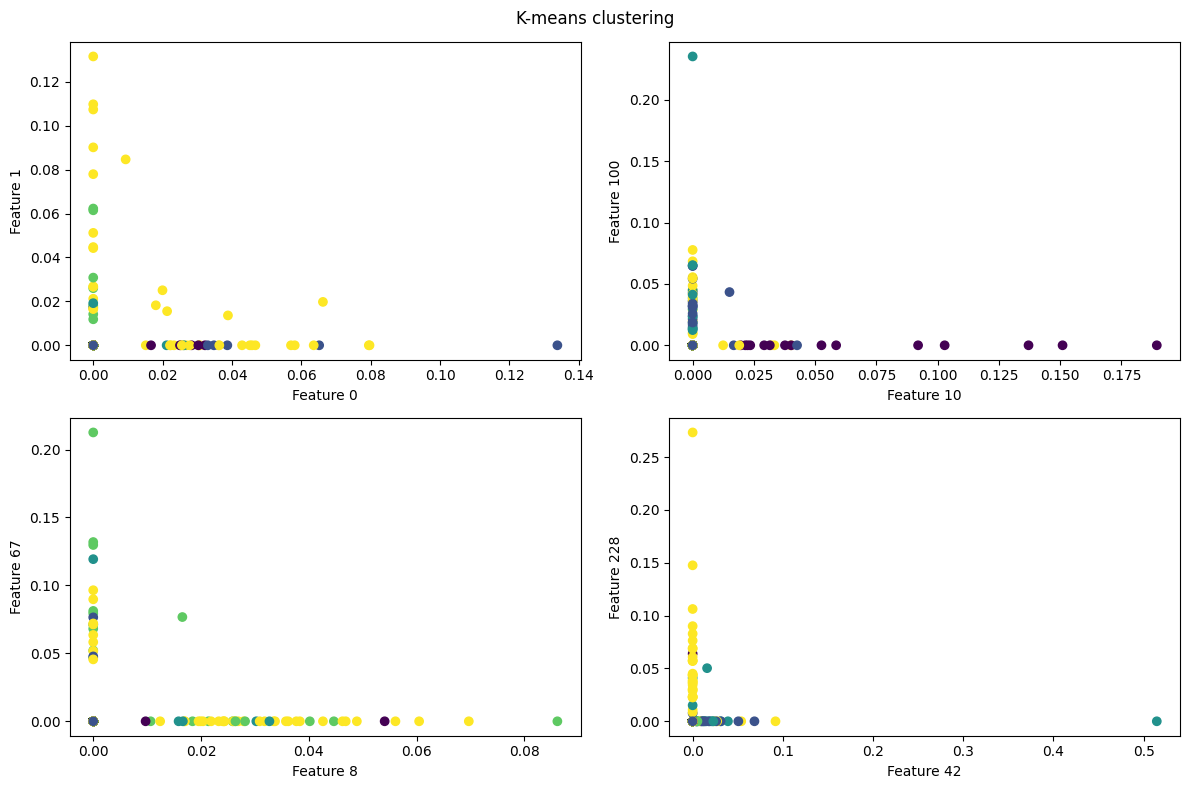

In [14]:
import matplotlib.pyplot as plt

# -- YOUR CODE HERE --
feature = [(0, 1), (10, 100), (8, 67), (42, 228)]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, (f1, f2) in zip(axes, feature):
    scatter = ax.scatter(ratings1[:, f1], ratings1[:, f2], c=clusters)
    ax.set_xlabel(f'Feature {f1}')
    ax.set_ylabel(f'Feature {f2}')
plt.suptitle('K-means clustering')
plt.tight_layout()
plt.show()

**Ответ:** визуализация получилась такой, потому что признаками у нас являются отдельные пользователи, поэтому, в целом, у нас точки часто имеют хотя бы одну нулевую координату (один из пользователей просто не слушает), из-за чего они располгаются по границе. Они не очень хорошо отражают разделение на кластеры, потому что, люди могут слушать музыку не только из одного кластера, + у всех людей разная длительность прослушивания. По таким графиам мы не можем визуально разделить кластеры друг от друга, ведь они сранивают отдельно рандомно взятых пользователей и точк часто накладываются друг на друга и вообще из-за формата признаков не очень интерпретируемо само разложение на кластеры

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

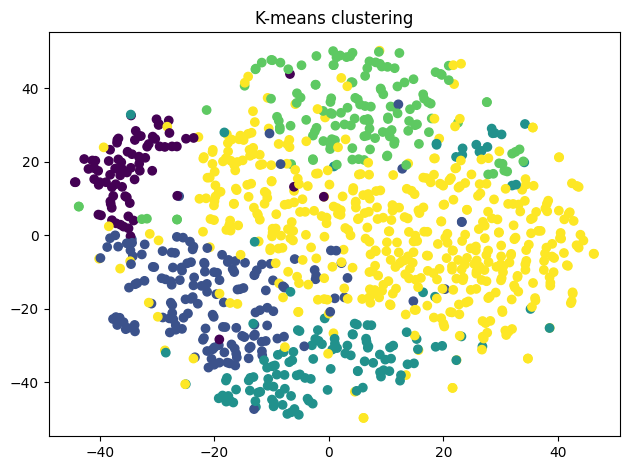

In [15]:
from sklearn.manifold import TSNE

# -- YOUR CODE HERE --
tsne = TSNE(n_components=2, random_state=42)
ratings2 = tsne.fit_transform(ratings1)

plt.scatter(ratings2[:, 0], ratings2[:, 1], c=clusters)
plt.title('K-means clustering')
plt.tight_layout()
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [18]:
from sklearn.metrics import silhouette_score

# -- YOUR CODE HERE --
import numpy as np
best_k, best_score = None, -1

for k in range(2, 30):
    k_means = KMeans(n_clusters = k, random_state=42)
    k_means = k_means.fit(ratings1)
    clusters = k_means.predict(ratings1)
    score = np.round(silhouette_score(X=ratings1,
                             labels=clusters), 2)
    print(k, score)

    if score > best_score:
      best_score = score
      best_k = k
print('Best score {}, k = {}'.format(best_score, best_k))

2 0.0
3 0.01
4 0.01
5 0.01
6 0.01
7 0.01
8 0.01
9 0.01
10 0.01
11 0.01
12 0.01
13 0.01
14 0.01
15 0.01
16 0.01
17 0.01
18 0.01
19 0.01
20 0.01
21 0.01
22 0.01
23 0.01
24 0.01
25 0.01
26 0.01
27 0.01
28 0.01
29 0.01
Best score 0.01, k = 3


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [20]:
# -- YOUR CODE HERE --
k_means = KMeans(n_clusters = 3, random_state=42)
k_means = k_means.fit(ratings1)
clusters = k_means.predict(ratings1)
centroids = k_means.cluster_centers_
for i in range(3):
    need_object = ratings[clusters == i]
    dist = need_object.apply(lambda x: cosine(x, centroids[i]), axis=1).sort_values()
    print(f'Кластер {i} : {dist.index[:10]}')

Кластер 0 : Index(['nas', 'kanye west', 'jay-z', 'a tribe called quest',
       'the roots featuring d'angelo', 'metallica', 'system of a down',
       'lupe the gorilla', 'mos def', 'tool'],
      dtype='object')
Кластер 1 : Index(['fall out boy', 'paramore', 'the all-americian rejects',
       'dashboard confesssional', 'john mayer', 'kelly clarkson', 'maroon5',
       'coldplay', 'the fray', 'the killers'],
      dtype='object')
Кластер 2 : Index(['radiohead', 'the arcade fire', 'belle and sebastian', 'sufjan stevens',
       'the shins', 'the pixies', 'broken social scene', 'animal collective',
       'deathcab for cutie', 'modest mouse'],
      dtype='object')


**Ответ:** само разделение по класрам все также происходит на основе разделения на представителей разных жанров, но сейчас оно стало менее дробным. Поразительно, но в один кластер (кластер 0) попали канье вест и металика, поэтому этот кластер предстваляет собой объединение хип-хоп и классичесикх рок исполнителей, вероятно слушатели выбирают их еще и за эпотажность. Другой кластер (кластер 1) уже включает в себя преимиущественно американский поп-рок, при этом группы в этой категории уже скорее потеряли свой маштабный успех и их слушают преданные фанаты. И поледний кластер (кластер 2) альернативная инди музыка, в которой акцент делатся скорее на эмоции и текст

Сделайте t-SNE визуализацию полученной кластеризации.

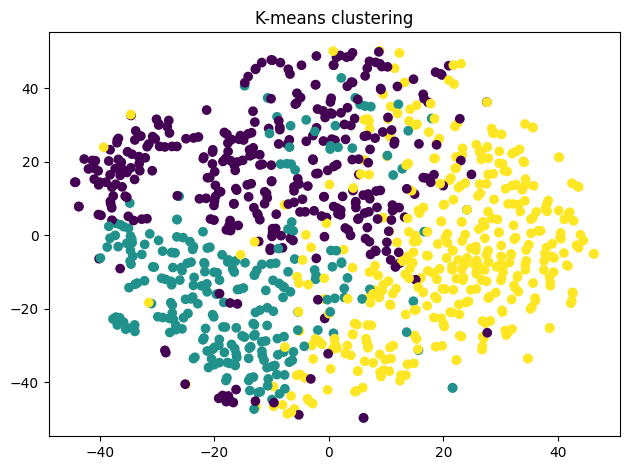

In [28]:
# -- YOUR CODE HERE --
tsne = TSNE(n_components=2, random_state=42)
ratings2 = tsne.fit_transform(ratings1)

plt.scatter(ratings2[:, 0], ratings2[:, 1], c=clusters)
plt.title('K-means clustering')
plt.tight_layout()
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

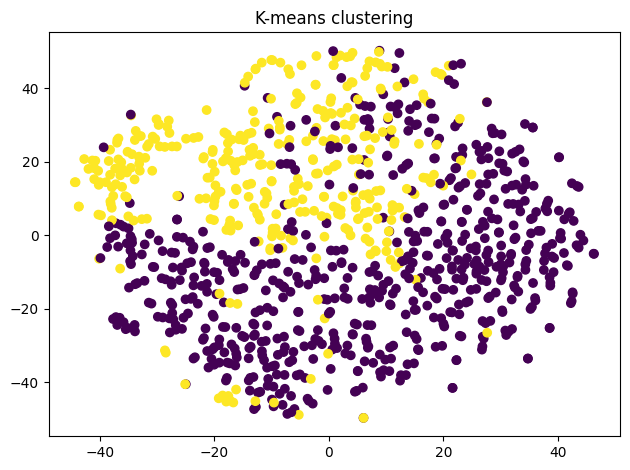

In [32]:
# -- YOUR CODE HERE --
plt.scatter(ratings2[:, 0], ratings2[:, 1], c = (clusters == 0))
plt.title('K-means clustering')
plt.tight_layout()
plt.show()

**Ответ:** я покрасила кластер 0 (как раз тот где и хип-хоп и рок) в целом мы видим, что точки действительно распоожены довольно былико друг к другу, конечно есть пересечаение с другими кластерами и отдельные выбросы, но в целом, точки группируются рядом, а это значит, что люди, которые слушают металику и люди, которые слушают канье веста, реально отностятся к одному кластеру и имеют схожий вкус